In [ ]:
import os
import sys
import copy
import joblib

sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import torch

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import property_driven_ml.logics as logics
import property_driven_ml.training as training

from withProperties.attack_ import (
    DoSHttpFloodPostcondition,
    TabularRuleConstraint,
    PortscanPostcondition,
    GlobalBounds
)
from sklearn.model_selection import train_test_split
from utils.utils import *
from sklearn.preprocessing import StandardScaler
from utils.models import build_model
from specs import ATTACK_SPECS
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

In [ ]:
TARGET_LABELS = ["BENIGN", "DOS_HTTP_FLOOD", "PORTSCAN"]
PROPERTY_MODEL_FEATURES = MODEL_NUMERIC_FEATURES + ENGINEERED_FEATURES
FEATURE_COLS = PROPERTY_MODEL_FEATURES

label_to_idx = {label: i for i, label in enumerate(TARGET_LABELS)}
idx = {name: i for i, name in enumerate(FEATURE_COLS)}

BOOLEAN_FEATURES = ["valid_tcp_handshake", "valid_http_conn"]
FROZEN_FEATURES = [
    "valid_tcp_handshake",
    "valid_http_conn",
    "uniq_dst_ports",
    "pkts_per_port",
    "scan_duration",
    "fail_ratio",
]

FROZEN_IDXS = [idx[f] for f in FROZEN_FEATURES if f in idx]

BATCH_SIZE = 1024
VAL_SIZE = 0.2
RANDOM_STATE = 42
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

LAMBDA_DOS = 2.0
LAMBDA_SCAN = 0.1
PGD_STEPS = 10
PGD_RESTARTS = 1
PGD_STEP_SIZE = 0.01

In [ ]:
raw_train_df = pd.read_csv("../data/ciciot2023_preprocessed_small.tsv", on_bad_lines="skip", delimiter="\t")
# df_cicids2017 = pd.read_csv("../data/cicids2017_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023 = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")

print_section("Loading data")
print_df_summary(raw_train_df, "Raw CICIDS2017 train")

train_full_df = filter_labels(raw_train_df, TARGET_LABELS, label_to_idx)

print("Training set label distribution before split:")
print_label_distribution(train_full_df)

train_df, val_df = train_test_split(
    train_full_df,
    test_size=VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=train_full_df["label"],
)


Loading data

Raw CICIDS2017 train summary
rows: 927,023
columns: 23

Label distribution:
BENIGN                count=  625030  ratio=0.6742
DOS_HTTP_FLOOD        count=  147959  ratio=0.1596
PORTSCAN              count=  154034  ratio=0.1662

Adding engineered features
input rows: 927,023
output rows: 927,023
engineered features: orig_pkt_rate, orig_byte_rate, time_elapsed, valid_tcp_handshake, valid_http_conn, uniq_dst_ports, pkts_per_port, scan_duration, fail_ratio
Training set label distribution before split:
BENIGN                count=  625030  ratio=0.6742
DOS_HTTP_FLOOD        count=  147959  ratio=0.1596
PORTSCAN              count=  154034  ratio=0.1662


In [ ]:
train_df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,valid_http_conn,orig_pkt_rate,orig_byte_rate,window_id,is_failed_conn,uniq_dst_ports,pkts_per_port,scan_duration,fail_ratio,label_id
255675,1.499450e+09,CtPEtX2ZAmLg6B5Nmi,172.16.0.1,50952,192.168.10.50,65000,tcp,-,0.000023,0.0,...,0,43478.260870,0.000000,299890021,1,997,4.040120,0.001429,1.000000,2
640714,1.499268e+09,CSxmXH1e2z39Tf8zUl,192.168.10.3,60389,192.168.10.1,53,udp,dns,0.048142,43.0,...,0,20.771883,893.190977,299853516,0,1,3.000000,0.060609,0.000000,0
862012,1.499436e+09,Cycj8J2y9MnHY37eWf,192.168.10.8,3144,192.95.33.211,443,tcp,ssl,10.583099,1014.0,...,1,1.039393,95.813145,299887280,0,4,258.000000,185.326984,0.022727,0
852941,1.499438e+09,Cj03lQ3Hmxdwk9SaMf,192.168.10.8,53781,192.168.10.3,53,udp,dns,0.000213,66.0,...,0,9389.671362,309859.154930,299887570,0,2,3.000000,0.000213,0.250000,0
501701,1.499452e+09,CeqtKv3pxJcdMBGJdl,192.168.10.16,44036,23.52.155.27,80,tcp,http,282.992418,4319.0,...,1,0.180217,15.261893,299890330,0,3,566.333333,282.992418,0.000000,0


# Scaling and Dataloaders

In [ ]:
def make_loader(df: pd.DataFrame, feature_cols: list[str], batch_size: int = 1024, shuffle: bool = False) -> DataLoader:
    x = torch.tensor(df[feature_cols].to_numpy(), dtype=torch.float32)
    y = torch.tensor(df["label_id"].to_numpy(), dtype=torch.long)
    return DataLoader(TensorDataset(x, y), batch_size=batch_size, shuffle=shuffle)


def scale_value(col: str, raw_value: float, scaler: StandardScaler, scale_cols: list[str]) -> float:
    i = scale_cols.index(col)
    return (raw_value - scaler.mean_[i]) / scaler.scale_[i]


def make_scaled_attack_specs(raw_specs: dict, scaler: StandardScaler, scale_cols: list[str]) -> dict:
    specs = copy.deepcopy(raw_specs)
    scale_map = {
        "validity": {
            "valid_packet_size_min_pkts": "orig_pkts",
            "valid_packet_size_min_total_bytes": "orig_bytes",
        },
        "dos_http_flood": {
            "mal_time_elapsed_min": "time_elapsed",
            "mal_time_elapsed_max": "time_elapsed",
            "valid_pkt_size_total_min": "orig_bytes",
            "mal_byte_rate_min": "orig_byte_rate",
            "mal_pkt_rate_min": "orig_pkt_rate",
        },
        "portscan": {
            "min_uniq_dst_ports": "uniq_dst_ports",
            "max_pkts_per_port": "pkts_per_port",
            "max_scan_duration": "scan_duration",
            "min_fail_ratio": "fail_ratio",
        },
    }

    for attack_name, key_to_col in scale_map.items():
        for spec_key, col in key_to_col.items():
            specs[attack_name][spec_key] = scale_value(col, raw_specs[attack_name][spec_key], scaler, scale_cols)

    return specs

In [ ]:
scale_cols = [col for col in FEATURE_COLS if col not in BOOLEAN_FEATURES]
scaler = StandardScaler()

train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
val_df[scale_cols] = scaler.transform(val_df[scale_cols])

scaled_attack_specs = make_scaled_attack_specs(ATTACK_SPECS, scaler, scale_cols)

train_loader = make_loader(train_df, FEATURE_COLS, batch_size=BATCH_SIZE, shuffle=True)
val_loader = make_loader(val_df, FEATURE_COLS, batch_size=BATCH_SIZE)

In [ ]:
train_df.head()

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,valid_http_conn,orig_pkt_rate,orig_byte_rate,window_id,is_failed_conn,uniq_dst_ports,pkts_per_port,scan_duration,fail_ratio,label_id
255675,1.499450e+09,CtPEtX2ZAmLg6B5Nmi,172.16.0.1,50952,192.168.10.50,65000,tcp,-,-0.251670,-0.027724,...,0,0.300869,-0.068787,299890021,1,2.190401,-0.440040,-0.665551,1.723605,2
640714,1.499268e+09,CSxmXH1e2z39Tf8zUl,192.168.10.3,60389,192.168.10.1,53,udp,dns,-0.250472,-0.027723,...,0,-0.170674,-0.068538,299853516,0,-0.459590,-0.440195,-0.665238,-0.792219,0
862012,1.499436e+09,Cycj8J2y9MnHY37eWf,192.168.10.8,3144,192.95.33.211,443,tcp,ssl,0.011901,-0.027699,...,1,-0.170888,-0.068761,299887280,0,-0.451608,-0.402171,0.315256,-0.735041,0
852941,1.499438e+09,Cj03lQ3Hmxdwk9SaMf,192.168.10.8,53781,192.168.10.3,53,udp,dns,-0.251665,-0.027723,...,0,-0.069015,0.017544,299887570,0,-0.456930,-0.440195,-0.665558,-0.163263,0
501701,1.499452e+09,CeqtKv3pxJcdMBGJdl,192.168.10.16,44036,23.52.155.27,80,tcp,http,6.796255,-0.027618,...,1,-0.170897,-0.068783,299890330,0,-0.454269,-0.356194,0.832135,-0.792219,0


# Setup model and constraints

In [ ]:
logic = logics.GoedelFuzzyLogic()
# bool_logic = logics.BooleanLogic()

lower_bound = torch.tensor(
    train_df[FEATURE_COLS].min().to_numpy(),
    dtype=torch.float32,
    device=device,
)

upper_bound = torch.tensor(
    train_df[FEATURE_COLS].max().to_numpy(),
    dtype=torch.float32,
    device=device,
)

model = build_model(
    model_type="mlp",
    n_features=len(FEATURE_COLS),
    num_classes=len(label_to_idx),
).to(device)

In [ ]:
precondition=GlobalBounds(
    device=device,
    lower_bound=lower_bound,
    upper_bound=upper_bound
)

dos_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=DoSHttpFloodPostcondition(
        idx=idx,
        class_idx=label_to_idx["DOS_HTTP_FLOOD"],
        dos_http_flood_specs=scaled_attack_specs["dos_http_flood"],
        validity_specs=scaled_attack_specs["validity"],
        min_prob=0.50
    )
)

scan_constraint = TabularRuleConstraint(
    device,
    precondition=precondition,
    postcondition=PortscanPostcondition(
        idx=idx,
        class_idx=label_to_idx["PORTSCAN"],
        min_prob=0.75,
        portscan_specs=scaled_attack_specs["portscan"]
    )
)

## Train Helpers

In [ ]:
def clamp_to_bounds(x_adv: torch.Tensor, lower_bound: torch.Tensor, upper_bound: torch.Tensor) -> torch.Tensor:
    return torch.max(torch.min(x_adv, upper_bound), lower_bound)


def project_x_adv(
    x_adv: torch.Tensor,
    x: torch.Tensor,
    lower_bound: torch.Tensor,
    upper_bound: torch.Tensor,
    frozen_idxs: list[int],
) -> torch.Tensor:
    x_adv = clamp_to_bounds(x_adv, lower_bound, upper_bound).clone()
    x_adv[:, frozen_idxs] = x[:, frozen_idxs]
    return x_adv


def update_rule_stats_for_label(stats: dict, parts: dict, y: torch.Tensor, class_idx: int) -> None:
    label_mask = y == class_idx

    for name, mask in parts.items():
        filtered_mask = mask.detach().bool()[label_mask]
        stats.setdefault(name, {"true": 0, "total": 0})
        stats[name]["true"] += filtered_mask.sum().item()
        stats[name]["total"] += filtered_mask.numel()


def print_rule_stats(name: str, stats: dict) -> None:
    print(f"\n{name} rule debug - true-label rows only")

    for part_name, values in stats.items():
        true = values["true"]
        total = values["total"]
        print(f"{part_name:25s} {true:8d}/{total:<8d}  {true / max(total, 1):.4f}")


def make_weighted_ce_loss(train_df: pd.DataFrame, device: torch.device) -> nn.CrossEntropyLoss:
    class_counts = train_df["label_id"].value_counts().sort_index().to_numpy()
    class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
    class_weights = (class_weights / class_weights.mean()).to(device)

    print("class_counts:", class_counts)
    print("class_weights:", class_weights)
    return nn.CrossEntropyLoss(weight=class_weights)

# Training

In [ ]:
def train_one_epoch(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    oracle: training.PGD,
    logic,
    ce_fn
) -> dict:
    model.train()
    totals = {"ce_loss": 0.0, "dos_loss": 0.0, "scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}

    for x, y in train_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        ce_loss = ce_fn(logits, y)

        x_adv_dos = oracle.attack(model, x, None, dos_constraint)
        x_adv_dos = project_x_adv(x_adv_dos, x, lower_bound, upper_bound, FROZEN_IDXS)
        dos_loss, dos_sat = dos_constraint.eval(model, x, x_adv_dos, None, logic, reduction="mean")

        x_adv_scan = oracle.attack(model, x, None, scan_constraint)
        x_adv_scan = project_x_adv(x_adv_scan, x, lower_bound, upper_bound, FROZEN_IDXS)
        scan_loss, scan_sat = scan_constraint.eval(model, x, x_adv_scan, None, logic, reduction="mean")

        loss = ce_loss + LAMBDA_DOS * dos_loss + LAMBDA_SCAN * scan_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        totals["ce_loss"] += ce_loss.item()
        totals["dos_loss"] += dos_loss.item()
        totals["scan_loss"] += scan_loss.item()
        totals["dos_sat"] += dos_sat.item()
        totals["scan_sat"] += scan_sat.item()

        with torch.no_grad():
            update_rule_stats_for_label(
                dos_debug_stats,
                dos_constraint.postcondition.debug_parts(model, x, x_adv_dos),
                y,
                label_to_idx["DOS_HTTP_FLOOD"],
            )
            update_rule_stats_for_label(
                scan_debug_stats,
                scan_constraint.postcondition.debug_parts(model, x, x_adv_scan),
                y,
                label_to_idx["PORTSCAN"],
            )

    batches = len(train_loader)
    metrics = {key: value / batches for key, value in totals.items()}
    metrics["dos_debug_stats"] = dos_debug_stats
    metrics["scan_debug_stats"] = scan_debug_stats
    return metrics


@torch.no_grad()
def validate(
    model: nn.Module,
    val_loader: DataLoader
) -> dict:
    model.eval()
    correct = 0.0
    dos_sat_total = 0.0
    scan_sat_total = 0.0
    n = 0

    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        _, dos_sat = dos_constraint.eval(model, x, x, None, logic, reduction="sum")
        _, scan_sat = scan_constraint.eval(model, x, x, None, logic, reduction="sum")

        correct += (preds == y).float().sum().item()
        dos_sat_total += dos_sat.item()
        scan_sat_total += scan_sat.item()
        n += x.size(0)

    return {
        "val_acc": correct / n,
        "val_dos_sat": dos_sat_total / n,
        "val_scan_sat": scan_sat_total / n,
    }

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
oracle = training.PGD(logic, device, steps=PGD_STEPS, restarts=PGD_RESTARTS, step_size=PGD_STEP_SIZE)
ce_fn = make_weighted_ce_loss(train_df, device=device)

PGD steps=10 restarts=1 step_size=tensor([0.0100], device='cuda:0')
class_counts: [500024 118367 123227]
class_weights: tensor([0.3232, 1.3653, 1.3115], device='cuda:0')


In [ ]:
for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = train_one_epoch(
        model = model,
        optimizer = optimizer,
        oracle = oracle,
        logic = logic,
        ce_fn = ce_fn
    )
    val_metrics = validate(model, val_loader)

    print(
        f"epoch={epoch} "
        f"ce_loss={train_metrics['ce_loss']:.4f} "
        f"dos_loss_avg={train_metrics['dos_loss']:.4f} "
        f"scan_loss_avg={train_metrics['scan_loss']:.4f} "
        f"dos_sat_avg={train_metrics['dos_sat']:.4f} "
        f"scan_sat_avg={train_metrics['scan_sat']:.4f} "
        f"val_acc={val_metrics['val_acc']:.4f} "
        f"val_dos_sat={val_metrics['val_dos_sat']:.4f} "
        f"val_scan_sat={val_metrics['val_scan_sat']:.4f}"
    )

    print_rule_stats("DoS HTTP Flood", train_metrics["dos_debug_stats"])
    print_rule_stats("Portscan", train_metrics["scan_debug_stats"])

epoch=1 ce_loss=0.0989 dos_loss_avg=0.0011 scan_loss_avg=0.1272 dos_sat_avg=0.9846 scan_sat_avg=0.9891 val_acc=0.9859 val_dos_sat=0.9519 val_scan_sat=0.9999

DoS HTTP Flood rule debug - true-label rows only
valid_tcp_handshake         117840/118367    0.9955
valid_http_conn             118367/118367    1.0000
mal_time_elapsed_min        118367/118367    1.0000
mal_time_elapsed_max        118367/118367    1.0000
valid_pkt_size_total_min    118367/118367    1.0000
high_byte_rate              116570/118367    0.9848
high_pkt_rate               116503/118367    0.9843
prediction_ok               111639/118367    0.9432
malicious_signal            117076/118367    0.9891
antecedent_true             116550/118367    0.9846

Portscan rule debug - true-label rows only
many_dst_ports              122424/123227    0.9935
high_fail_ratio             122551/123227    0.9945
low_pkts_per_port           122984/123227    0.9980
short_scan_duration         111800/123227    0.9073
prediction_ok        

#

In [ ]:
def save_property_model(
    model,
    save_path,
    features,
    model_type,
    scaler
):
    joblib.dump(
        {
            "model": model.cpu(),
            "features": features,
            "model_type": model_type,
            "scaler": scaler
        },
        save_path,
    )

    print(f"Saved model to: {save_path}")

In [ ]:
save_property_model(
    model,
    "models/property_model_cicids2017_3_classes.joblib",
    features=FEATURE_COLS,
    model_type="mlp",
    scaler=scaler
)

Saved model to: models/property_model_cicids2017_3_classes.joblib


In [ ]:
import joblib
bundle = joblib.load("models/property_model_cicids2017_3_classes.joblib")
print(bundle.keys())

dict_keys(['model', 'features', 'model_type', 'scaler'])


# Evaluate cross-data

In [ ]:
def prepare_eval_df(
    df: pd.DataFrame,
    target_labels: list[str],
    label_to_idx: dict[str, int],
    scaler: StandardScaler
) -> pd.DataFrame:
    df = filter_labels(df, target_labels, label_to_idx)
    df[scale_cols] = scaler.transform(df[scale_cols])
    return df

df_ciciot2023_train = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")
cross_eval_df = prepare_eval_df(df_ciciot2023_train, TARGET_LABELS, label_to_idx, scaler)

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_25028\1937919784.py:11: DtypeWarning: Columns (0: duration, 1: orig_bytes, 2: resp_bytes) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ciciot2023_train = pd.read_csv("../data/ciciot2023_preprocessed.tsv", on_bad_lines="skip", delimiter="\t")



Adding engineered features
input rows: 2,922,697
output rows: 2,922,697
engineered features: orig_pkt_rate, orig_byte_rate, time_elapsed, valid_tcp_handshake, valid_http_conn, uniq_dst_ports, pkts_per_port, scan_duration, fail_ratio


In [ ]:
def print_attack_feature_stats(df: pd.DataFrame, label: str, cols: list[str]) -> None:
    print(f"\nTrue {label} scaled stats")
    print(
        df.loc[df["label"] == label, cols]
        .describe(percentiles=[0.25, 0.5, 0.75, 0.99])
    )
    
print_attack_feature_stats(
    cross_eval_df,
    "DOS_HTTP_FLOOD",
    ["time_elapsed", "orig_bytes", "orig_pkts", "orig_pkt_rate", "orig_byte_rate", "valid_tcp_handshake", "valid_http_conn"],
)

print_attack_feature_stats(
    cross_eval_df,
    "PORTSCAN",
    ["uniq_dst_ports", "fail_ratio", "pkts_per_port", "scan_duration"],
)


True DOS_HTTP_FLOOD scaled stats
        time_elapsed     orig_bytes      orig_pkts  orig_pkt_rate  \
count  145451.000000  145451.000000  145451.000000  145451.000000   
mean       -0.169046      -0.027407       0.002884      -0.170671   
std         0.370144       0.000428       0.007964       0.001256   
min        -0.194565      -0.027724      -0.005484      -0.170899   
25%        -0.194565      -0.027680      -0.001971      -0.170892   
50%        -0.194565      -0.027404       0.001543      -0.170885   
75%        -0.194565      -0.027303       0.004554      -0.170853   
99%        -0.194175      -0.026610       0.021117      -0.165372   
max         5.289555       0.020785       1.037009      -0.136598   

       orig_byte_rate  valid_tcp_handshake  valid_http_conn  
count   145451.000000        145451.000000    145451.000000  
mean        -0.068280             0.839898         0.933462  
std          0.001138             0.366702         0.249221  
min         -0.068787      

In [ ]:
@torch.no_grad()
def evaluate_model_metrics(
    model: nn.Module,
    df: pd.DataFrame,
    batch_size: int = 1024,
) -> tuple[dict, pd.DataFrame, np.ndarray, list[str]]:
    loader = make_loader(df, FEATURE_COLS, batch_size=batch_size)
    idx_to_label = {v: k for k, v in label_to_idx.items()}
    label_ids = list(range(len(idx_to_label)))
    labels = [idx_to_label[i] for i in label_ids]

    model = model.to(device)
    model.eval()

    y_true, y_pred = [], []
    totals = {"dos_loss": 0.0, "scan_loss": 0.0, "dos_sat": 0.0, "scan_sat": 0.0}
    dos_debug_stats, scan_debug_stats = {}, {}
    n = 0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        preds = logits.argmax(dim=1)

        dos_loss, dos_sat = dos_constraint.eval(model, x, x, None, logic, reduction="sum")
        scan_loss, scan_sat = scan_constraint.eval(model, x, x, None, logic, reduction="sum")

        update_rule_stats_for_label(
            dos_debug_stats,
            dos_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["DOS_HTTP_FLOOD"],
        )
        update_rule_stats_for_label(
            scan_debug_stats,
            scan_constraint.postcondition.debug_parts(model, x, x),
            y,
            label_to_idx["PORTSCAN"],
        )

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

        totals["dos_loss"] += dos_loss.item()
        totals["scan_loss"] += scan_loss.item()
        totals["dos_sat"] += dos_sat.item()
        totals["scan_sat"] += scan_sat.item()
        n += x.size(0)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    report = classification_report(
        y_true,
        y_pred,
        labels=label_ids,
        target_names=labels,
        digits=4,
        zero_division=0,
        output_dict=True,
    )

    for label_id, label_name in zip(label_ids, labels):
        mask = y_true == label_id
        report[label_name]["accuracy"] = float((y_pred[mask] == label_id).mean()) if mask.sum() else 0.0

    metrics = {
        "acc": float((y_true == y_pred).mean()),
        "dos_loss": totals["dos_loss"] / max(n, 1),
        "scan_loss": totals["scan_loss"] / max(n, 1),
        "dos_sat": totals["dos_sat"] / max(n, 1),
        "scan_sat": totals["scan_sat"] / max(n, 1),
    }

    print_rule_stats("Cross-dataset DoS HTTP Flood", dos_debug_stats)
    print_rule_stats("Cross-dataset Portscan", scan_debug_stats)

    cm = confusion_matrix(y_true, y_pred, labels=label_ids)
    return metrics, pd.DataFrame(report).T, cm, labels

In [ ]:
metrics, report_df, cm, labels = evaluate_model_metrics(
    model,
    cross_eval_df
)


Cross-dataset DoS HTTP Flood rule debug - true-label rows only
valid_tcp_handshake         122164/145451    0.8399
valid_http_conn             135773/145451    0.9335
mal_time_elapsed_min        145451/145451    1.0000
mal_time_elapsed_max        144137/145451    0.9910
valid_pkt_size_total_min    124239/145451    0.8542
high_byte_rate              113849/145451    0.7827
high_pkt_rate                32441/145451    0.2230
prediction_ok                 4811/145451    0.0331
malicious_signal            116449/145451    0.8006
antecedent_true              87109/145451    0.5989

Cross-dataset Portscan rule debug - true-label rows only
many_dst_ports              143436/216533    0.6624
high_fail_ratio             152145/216533    0.7026
low_pkts_per_port           160055/216533    0.7392
short_scan_duration         180972/216533    0.8358
prediction_ok               155440/216533    0.7179
scan_signal                 205119/216533    0.9473
antecedent_true             143436/216533    0

In [ ]:
def plot_eval_summary(metrics, report_df, cm, labels, model_name):
    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        figsize=(11, 15),
        gridspec_kw={"height_ratios": [3, 1.2, 2.8]},
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax1,
    )
    ax1.set_xlabel("Predicted")
    ax1.set_ylabel("Actual")
    ax1.set_title(f"{model_name} Confusion Matrix")

    ax2.axis("off")
    metrics_text = "\n".join(
        [
            f"accuracy: {metrics['acc']:.3f}",
            f"dos_loss: {metrics['dos_loss']:.3f}",
            f"scan_loss: {metrics['scan_loss']:.3f}",
            f"dos_sat: {metrics['dos_sat']:.3f}",
            f"scan_sat: {metrics['scan_sat']:.3f}",
        ]
    )
    ax2.text(
        0.01,
        0.95,
        metrics_text,
        va="top",
        ha="left",
        family="monospace",
        fontsize=11,
    )

    ax3.axis("off")
    ax3.text(
        0.01,
        0.95,
        report_df.round(3).to_string(),
        va="top",
        ha="left",
        family="monospace",
        fontsize=9,
    )
    ax3.set_title("Classification Report + Per-Label Accuracy")

    plt.tight_layout()
    plt.show()

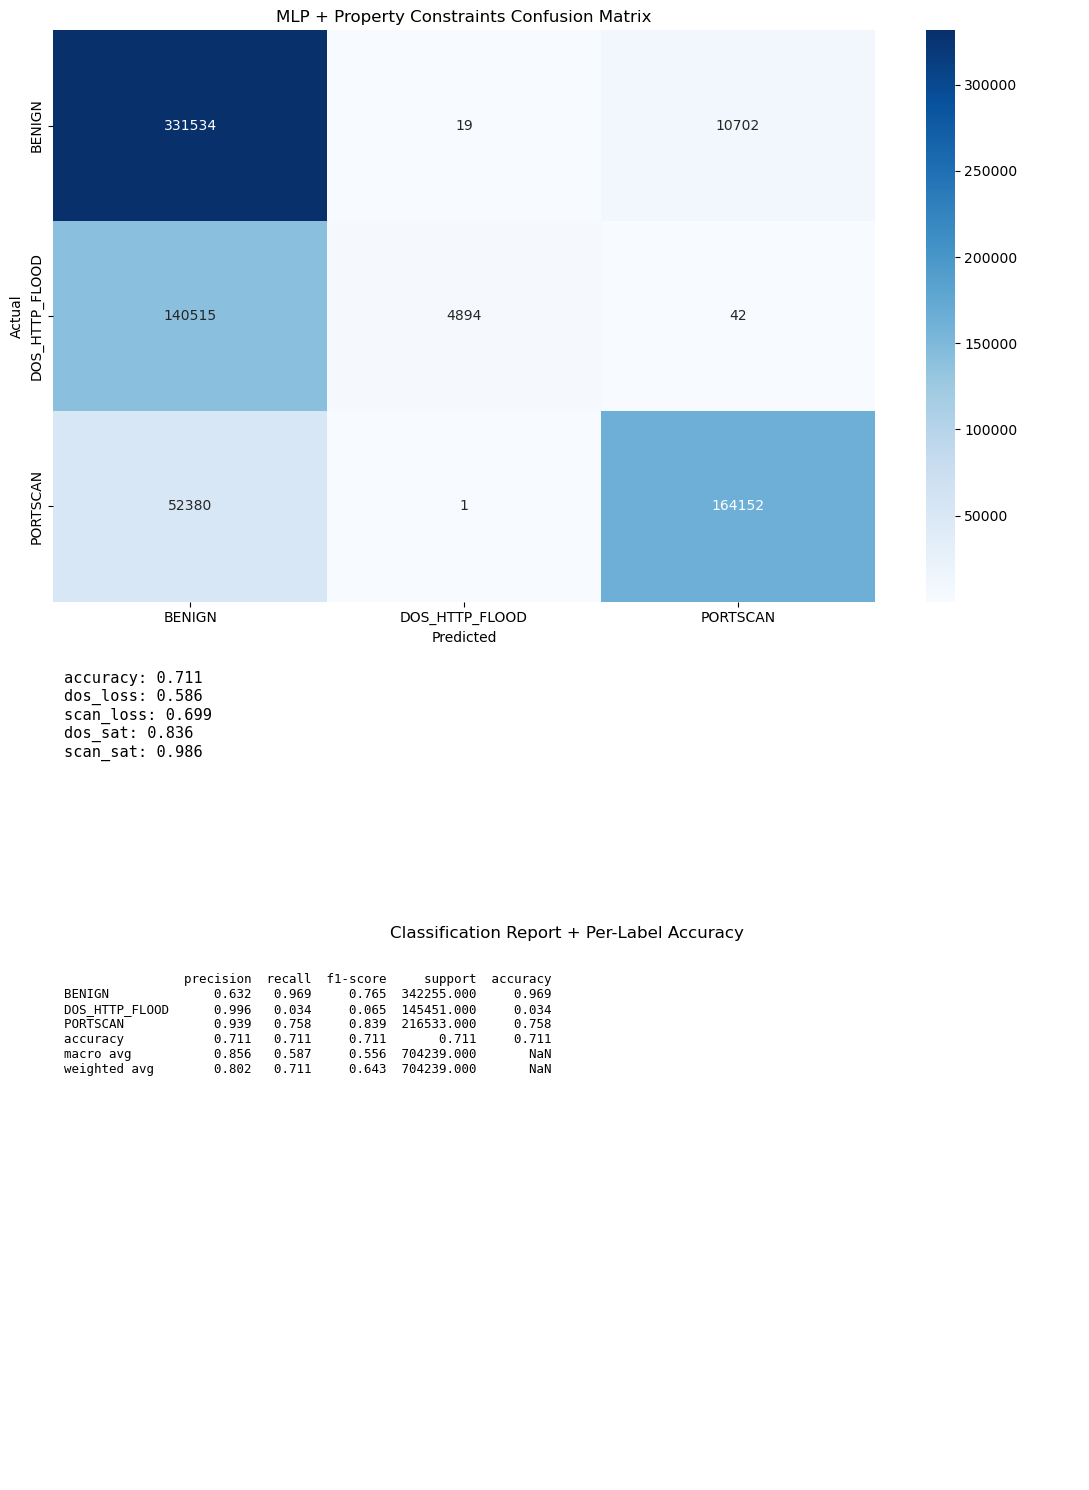

In [ ]:
plot_eval_summary(
    metrics,
    report_df,
    cm,
    labels,
    model_name="MLP + Property Constraints",
)